
# Anomaly Detection of Melanoma in Dermoscopic Images
### 50.039 Deep Learning Y2026
#### Group 16

| Student Name           | Student Number |
|------------------------|----------------|
| Gay Jun Han Dylan      | 1007831        |
| Lydia Rachel Robert    | 1008462        |
| Yeo Chun Sheng Joel    | 1008112        |

This notebook is a clean evaluation notebook.

Use it to:
- choose any checkpoint from `models/`
- auto-detect the saved architecture from the checkpoint keys
- load the validation and test sets from `data_new/`
- find the best validation threshold
- evaluate the selected model on the test set

In [6]:
import sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from torchvision.models import vit_b_16

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.models.cnn_batchnorm import BatchNormCNN
from src.models.cnn_batchnorm_deeper import DeeperBatchNormCNN
from src.models.cnn_batchnorm_residual import ResidualBatchNormCNN
from src.utils import find_best_threshold, evaluate_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [7]:
MODELS_DIR = ROOT / 'models'
TRAIN_CSV = ROOT / 'data_new/splits/train.csv'
VAL_CSV = ROOT / 'data_new/splits/val.csv'
TEST_CSV = ROOT / 'data_new/splits/test.csv'
TRAIN_IMAGE_DIR = ROOT / 'data_new/images/train'
TEST_IMAGE_DIR = ROOT / 'data_new/images/test'

BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 0

available_models = sorted(path.name for path in MODELS_DIR.glob('*.pth'))
if not available_models:
    raise FileNotFoundError(f'No .pth checkpoints found in {MODELS_DIR}')

display(pd.DataFrame({'available_models': available_models}))

# Change this to any checkpoint shown above.
SELECTED_MODEL = available_models[0]

print(f'Selected checkpoint: {SELECTED_MODEL}')

,available_models
0,cnn_baseline_weighted.pth
1,cnn_batchnorm_weighted.pth
2,cnn_deeper_batchnorm_weighted.pth
3,cnn_residual_batchnorm_weighted.pth
4,vit_b16_weighted.pth


Selected checkpoint: cnn_baseline_weighted.pth


In [8]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        return checkpoint['state_dict']
    if isinstance(checkpoint, dict):
        return checkpoint
    raise TypeError(f'Unsupported checkpoint type: {type(checkpoint)}')
def detect_checkpoint_format(state_dict):
    keys = list(state_dict.keys())

    if any(key.startswith('model.class_token') for key in keys):
        return 'vit_wrapped'

    if any(key.startswith('stem.') for key in keys):
        return 'cnn_residual_batchnorm'

    if any(key.startswith('features.') for key in keys):
        first_conv = state_dict.get('features.0.weight')

        if first_conv is not None and 'classifier.1.weight' in state_dict:
            classifier_in_features = int(state_dict['classifier.1.weight'].shape[1])
            has_batchnorm = any(key.startswith('features.1.running_') for key in keys)

            if has_batchnorm and classifier_in_features == 100352:
                return 'cnn_batchnorm'
            if has_batchnorm and classifier_in_features == 256:
                return 'cnn_deeper_batchnorm'
            if not has_batchnorm and classifier_in_features == 100352:
                return 'cnn_baseline'

    raise ValueError(
        'Could not detect a supported architecture from this checkpoint. '
        'If you added a new model family, extend detect_checkpoint_format() first.'
    )


def build_model_for_format(checkpoint_format):
    if checkpoint_format == 'cnn_baseline':
        return SimpleCNN(num_classes=1)

    if checkpoint_format == 'cnn_batchnorm':
        return BatchNormCNN(num_classes=1)

    if checkpoint_format == 'cnn_deeper_batchnorm':
        return DeeperBatchNormCNN(num_classes=1)

    if checkpoint_format == 'cnn_residual_batchnorm':
        return ResidualBatchNormCNN(num_classes=1)

    if checkpoint_format == 'vit_wrapped':
        model = vit_b_16(weights=None)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, 1)
        return model

    raise ValueError(f'Unsupported checkpoint format: {checkpoint_format}')


def normalize_state_dict_for_model(state_dict, checkpoint_format):
    if checkpoint_format == 'vit_wrapped':
        return {key.replace('model.', '', 1): value for key, value in state_dict.items()}

    return state_dict


def load_model_from_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    raw_state_dict = extract_state_dict(checkpoint)
    checkpoint_format = detect_checkpoint_format(raw_state_dict)
    model = build_model_for_format(checkpoint_format)
    state_dict = normalize_state_dict_for_model(raw_state_dict, checkpoint_format)

    try:
        model.load_state_dict(state_dict, strict=True)
    except RuntimeError as error:
        raise RuntimeError(
            f'Failed to load {checkpoint_path.name} as {checkpoint_format}.\n{error}'
        ) from error

    model = model.to(device)
    model.eval()

    return model, checkpoint_format


In [9]:
checkpoint_path = MODELS_DIR / SELECTED_MODEL
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(TRAIN_CSV),
    val_csv=str(VAL_CSV),
    test_csv=str(TEST_CSV),
    image_dir=str(TRAIN_IMAGE_DIR),
    test_image_dir=str(TEST_IMAGE_DIR),
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=NUM_WORKERS,
)

model, checkpoint_format = load_model_from_checkpoint(checkpoint_path, device)

print(f'Loaded checkpoint: {checkpoint_path.name}')
print(f'Detected architecture: {checkpoint_format}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Loaded checkpoint: cnn_baseline_weighted.pth
Detected architecture: cnn_baseline
Validation batches: 64
Test batches: 48


In [10]:
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)
print(f'Chosen threshold for test evaluation: {best_threshold:.2f}')

Best threshold: 0.49 | Val F2: 0.5945
Chosen threshold for test evaluation: 0.49


Threshold:          0.49
AUC-ROC:            0.8471
Balanced Accuracy:  0.7562
F2 Score:           0.5670

              precision    recall  f1-score   support

Non-Melanoma     0.9750    0.6410    0.7735      1340
    Melanoma     0.2365    0.8713    0.3720       171

    accuracy                         0.6671      1511
   macro avg     0.6058    0.7562    0.5728      1511
weighted avg     0.8914    0.6671    0.7281      1511



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


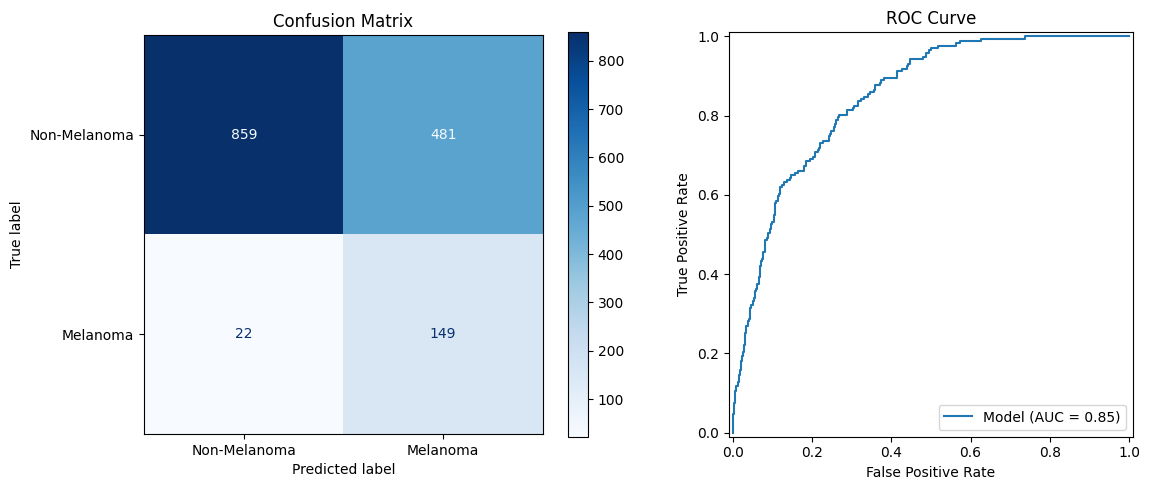

In [11]:
evaluate_model(model, test_loader, device, threshold=best_threshold)